In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<class 'numpy.ndarray'>


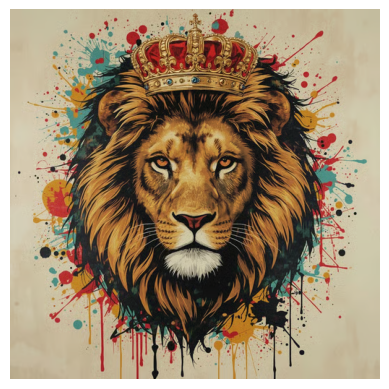

In [81]:
img = cv2.imread('../image/lena.jpg')
print(type(img))
plt.imshow(cv2.cvtColor(img,4))
plt.axis('off')
plt.show()

<class 'numpy.ndarray'>
(512, 512)
2


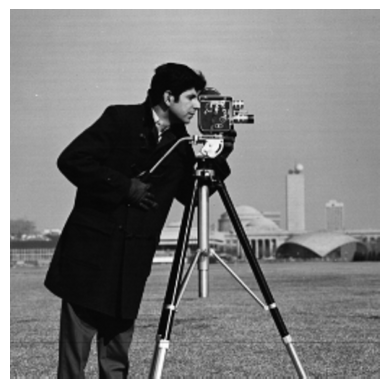

In [82]:
img_gray = cv2.imread('../image/cameraman.tif' , 0)
print(type(img_gray))
print(img_gray.shape)
print(img_gray.ndim)
plt.imshow(img_gray ,cmap='gray')
plt.axis('off')
plt.show()

In [83]:
def histogram_fixed(img):
    flatten_img = img.flatten()
    hist = np.zeros(256,dtype='int')
    for i in flatten_img :
        hist[i] += 1
    return hist

In [84]:
histogram_fixed(img_gray)

array([ 102,   76,   89,  114,  159,  209,  335, 1173, 3523, 5129, 4490,
       4980, 5762, 6212, 6067, 4480, 2805, 1375,  860,  625,  498,  503,
        426,  430,  379,  398,  418,  402,  358,  362,  354,  349,  355,
        381,  371,  379,  348,  375,  390,  398,  394,  349,  327,  345,
        311,  263,  256,  279,  274,  258,  258,  245,  242,  261,  265,
        268,  285,  276,  334,  308,  337,  309,  313,  370,  276,  301,
        245,  230,  244,  242,  222,  217,  230,  238,  235,  224,  205,
        220,  213,  208,  164,  203,  222,  216,  230,  243,  251,  281,
        315,  328,  334,  327,  333,  381,  417,  420,  473,  525,  573,
        620,  650,  687,  727,  760,  803,  816,  924,  986,  981, 1002,
       1085, 1070, 1174, 1202, 1219, 1190, 1314, 1321, 1432, 1399, 1453,
       1539, 1477, 1509, 1598, 1592, 1691, 1659, 1745, 1705, 1734, 1702,
       1663, 1598, 1655, 1673, 1626, 1556, 1435, 1435, 1398, 1449, 1391,
       1514, 1590, 1800, 1964, 2096, 2176, 2147, 22

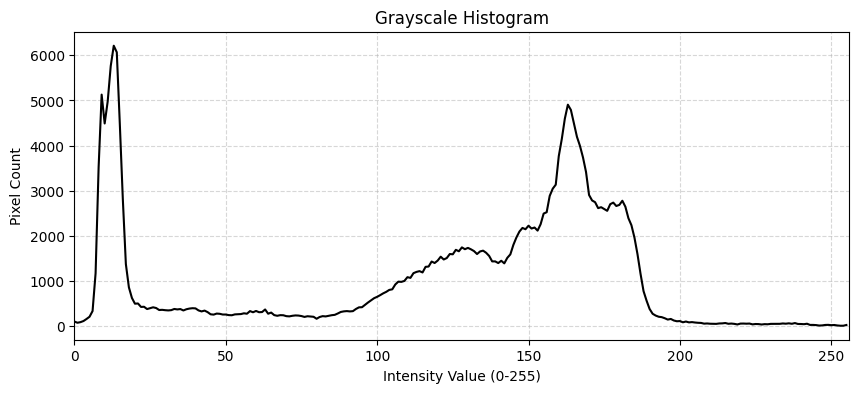

(256, 1)
(256,)


In [ ]:
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
# calcHist([img],[0],None,[256],[0,256])

plt.figure(figsize=(10, 4)) # Sizing
plt.plot(hist, color='black') # วาดกราฟเส้น
plt.title('Grayscale Histogram')
plt.xlabel('Intensity Value (0-255)')
plt.ylabel('Pixel Count')
plt.xlim([0, 256]) # บังคับให้แกน X เริ่มที่ 0 และจบที่ 255
plt.grid(True, linestyle='--', alpha=0.5) # ใส่เส้นตารางจางๆ ให้ดูง่าย
plt.show()

print(hist.shape)
print(hist.flatten().shape)

In [86]:
def intermean(hist , thr) :
    p = hist/hist.sum()
    
    indices = np.arange(256)
    i0 = indices[:thr]
    i1 = indices[thr:]
    
    p0 = p[:thr]
    p1 = p[thr:]
    
    w0 = p0.sum() + 1e-8
    w1 = p1.sum() + 1e-8
    
    u0 = (i0*p0).sum() / w0
    u1 = (i1*p1).sum() / w1
    
    if u0 == 0 :
        thr = u0
    elif u1 == 0 :
        thr = u1
    else :
        thr = (u0 + u1) / 2
    
    return int(np.round(thr))

In [87]:
currentThr = 127
while True :
    nextThr = intermean(hist , currentThr)
    print(f"CurrentThr = {currentThr} , NextThr = {nextThr}")
    if currentThr == nextThr :
        break
    currentThr = nextThr
print(f"currentThr = {currentThr}")

CurrentThr = 127 , NextThr = 108
CurrentThr = 108 , NextThr = 95
CurrentThr = 95 , NextThr = 89
CurrentThr = 89 , NextThr = 88
CurrentThr = 88 , NextThr = 88
currentThr = 88


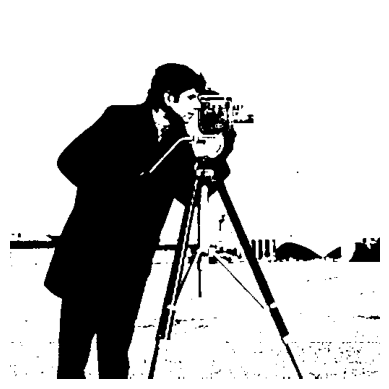

In [91]:
out = np.zeros_like(img_gray,dtype='int')
out[img_gray > currentThr] = 255
plt.imshow(out,cmap='gray')
plt.axis('off')
plt.show()